In [1]:
 %load_ext autoreload
%autoreload 2
import numpy as np
from utils_final_results import load_dataset
from hydra import compose
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error
from utils_table_generator import get_mean_std, flatten_config
from omegaconf import OmegaConf
import pandas as pd

/home/lcornelis/anaconda3/envs/proteo/lib/python3.11/site-packages/torch_geometric/typing.py:155: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /home/lcornelis/anaconda3/envs/proteo/lib/python3.11/site-packages/torch_spline_conv/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(
/home/lcornelis/code/TopoProteo/tutorials/utils_final_results.py:55: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../configs", job_name="job")


In [2]:
def construct_dataset(dataset):
    X_list = []
    y_list = []
    sex_list = []
    mutation_list = []
    age_list = []

    for data in dataset:
        graph_feat = data.x.view(-1).numpy()
        X_list.append(graph_feat)
        y_list.append(data.y.item())
        sex_list.append(data.sex.item())
        mutation_list.append(data.mutation.item())
        age_list.append(data.age.item())

    X = np.vstack(X_list)
    y = np.array(y_list)

    sex = np.array(sex_list).reshape(-1, 1)
    mutation = np.array(mutation_list).reshape(-1, 1)
    age = np.array(age_list).reshape(-1, 1)

    return X, y, sex, mutation, age


def stack_features(train_features, train_labels, train_sex, train_mutation, train_age, val_features, val_labels, val_sex, val_mutation, val_age):
    target_shape = train_features.shape[1] // 3
    if train_sex.shape[1] < target_shape:
        # Calculate how many times to repeat train_sex along the second axis
        repeat_times = target_shape // train_sex.shape[1]
        train_sex = np.tile(train_sex, (1, repeat_times))
        val_sex = np.tile(val_sex, (1, repeat_times))
        train_mutation = np.tile(train_mutation, (1, repeat_times))
        val_mutation = np.tile(val_mutation, (1, repeat_times))
        train_age = np.tile(train_age, (1, repeat_times))
        val_age = np.tile(val_age, (1, repeat_times))

    train_combined = np.hstack((train_features, train_sex, train_mutation, train_age))
    print(train_combined.shape)
    val_combined = np.hstack((val_features, val_sex, val_mutation, val_age))
    print(val_combined.shape)
    return train_combined, val_combined, train_labels, val_labels

def concat_features(train_features, train_labels, train_sex, train_mutation, train_age, val_features, val_labels, val_sex, val_mutation, val_age):
    train_combined = np.hstack((train_features, train_sex, train_mutation, train_age))
    val_combined = np.hstack((val_features, val_sex, val_mutation, val_age))
    return train_combined, val_combined, train_labels, val_labels

def convert_results(norm_mean, adj_metric, adj_thresh, k_fold, num_folds, fold) :
    cfg = compose(
        config_name="run.yaml",
        overrides=[
            "model=graph/gcn",
            "dataset=graph/FTD",
            f"dataset.loader.parameters.adj_metric={adj_metric}",
            f"dataset.loader.parameters.adj_thresh={adj_thresh}",
            f"dataset.loader.parameters.kfold={k_fold}",
            f"dataset.loader.parameters.num_folds={num_folds}",
            f"dataset.loader.parameters.fold={fold}",
            "dataset.loader.parameters.y_val=global_cog_slope",
            "dataset.loader.parameters.two_pass=True",
            "dataset.loader.parameters.num_nodes=3667",
        ],
        return_hydra_config=True
    )
    cfg_dict = OmegaConf.to_container(cfg, resolve=False)
    cfg_flat = flatten_config(cfg_dict)
    mean, std = get_mean_std(cfg_flat)
    assert mean is not None, "Mean is None for run"
    assert std is not None, "Std is None for run"
    orig_rmse = np.sqrt(norm_mean) * std
    # orig_std = norm_std * std**2
    return orig_rmse


def run_lasso_folds(num_folds=5, k_fold=True, expand_features=True, adj_metric="wgcna", adj_thresh=0.5):
    alphas = np.logspace(-4, 2, 50) # Range of alpha values to try
    # Dictionary to store MSE scores for each alpha
    alpha_results = {alpha: [] for alpha in alphas}
    alpha_results_orig = {alpha: [] for alpha in alphas}


    for fold in range(num_folds):
        [train, val, test] = load_dataset(adj_metric, adj_thresh, k_fold, num_folds, fold=fold, y_val="global_cog_slope", two_pass=True, num_nodes=3667)
        train_features, train_labels, train_sex, train_mutation, train_age = construct_dataset(train)
        _,_,feature_names, _, _, _, _, _ = train.load_csv_data_pre_pt_files(train.config)
        n = len(feature_names) // 3
        feature_names = np.array(list(feature_names) + ["sex"] * n + ["mutation"] * n + ["age"] * n)
        val_features, val_labels, val_sex, val_mutation, val_age = construct_dataset(val)
        if expand_features:
            train_combined, val_combined, train_labels, val_labels = stack_features(
                train_features, train_labels, train_sex, train_mutation, train_age,
                val_features, val_labels, val_sex, val_mutation, val_age
            )
        else:
            train_combined, val_combined, train_labels, val_labels = concat_features(
                train_features, train_labels, train_sex, train_mutation, train_age,
                val_features, val_labels, val_sex, val_mutation, val_age
            )

        print(f"Fold {fold}: Training on {train_combined.shape[0]} samples, validating on {val_combined.shape[0]} samples")

        # Try different alpha values
        best_alpha_fold = None
        best_mse_fold = float("inf")
        for alpha in alphas:
            lasso_model = Lasso(alpha=alpha, random_state=42)
            lasso_model.fit(train_combined, train_labels)

            # Predict and evaluate
            predictions = lasso_model.predict(val_combined)
            mse = mean_squared_error(val_labels, predictions)
            orig_rmse = convert_results(mse, adj_metric, adj_thresh, k_fold, num_folds, fold)
            alpha_results[alpha].append(mse)
            alpha_results_orig[alpha].append(orig_rmse)

            # track best alpha for THIS fold
            if mse < best_mse_fold:
                best_mse_fold = mse
                best_alpha_fold = alpha

        # Refit on train with the best alpha for this fold and SAVE COEFS
        best_model_fold = Lasso(alpha=best_alpha_fold, random_state=42)
        best_model_fold.fit(train_combined, train_labels)
        coefs = best_model_fold.coef_

        coef_df = pd.DataFrame(coefs, index=feature_names, columns=["coefficient"])
        coef_df.insert(0, "alpha", float(best_alpha_fold))
        coef_df.insert(0, "fold", fold + 1)  # 1-based for readability
        coef_df.reset_index(names="feature", inplace=True)
        out_path = f"lasso_coefficients_fold{fold+1}_of_{num_folds}.csv"
        coef_df.to_csv(out_path, index=False)
        print(f"Saved coefficients for fold {fold+1}/{num_folds} (alpha={best_alpha_fold:.3g}) to {out_path}")

        print(f"Completed fold {fold}")
    
    # Calculate and print statistics for each alpha
    print("\nResults for each alpha value across folds:")
    print("Alpha\tMean MSE ± Std MSE\tMean MSE (orig units) ± Std MSE (orig units)")
    print("-" * 30)
    
    best_mean_mse = float('inf')
    best_mean_orig = float('inf')
    best_alpha = None
    
    for alpha in alphas:
        mean_mse = np.mean(alpha_results[alpha])
        std_mse = np.std(alpha_results[alpha])
        mean_rmse_orig = np.mean(alpha_results_orig[alpha])
        std_rmse_orig = np.std(alpha_results_orig[alpha])
        print(f"{alpha:.3f}\t{mean_mse:.4f} ± {std_mse:.4f}\t{mean_rmse_orig:.4f} ± {std_rmse_orig:.4f}")

        if mean_mse < best_mean_mse:
            best_mean_mse = mean_mse
            best_mean_orig = mean_rmse_orig
            best_alpha = alpha
    
    print(f"\nBest alpha across all folds: {best_alpha} (MSE: {best_mean_mse:.4f})")
    
    return alpha_results


def get_age_sex_mutation_info(num_folds=5, k_fold=True, expand_features=True, adj_metric="pointcloud", adj_thresh=1.0):
    for fold in range(num_folds):
        [train, val, test] = load_dataset(adj_metric, adj_thresh, k_fold, num_folds, fold=fold, y_val="global_cog_slope")
        train_features, train_labels, train_sex, train_mutation, train_age = construct_dataset(train)
        val_features, val_labels, val_sex, val_mutation, val_age = construct_dataset(val)
        return(train_sex, train_mutation, train_age, val_sex, val_mutation, val_age)

In [3]:
import pandas as pd

df = pd.read_csv("/scratch/lcornelis/data/data_louisa/FTD/raw/cleanDat.Soma.CSFneat.5SDWinsor_merged.csv")

/tmp/ipykernel_3689587/3049662071.py:3: DtypeWarning: Columns (7621,7622,7694,7697,7698,7699) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/scratch/lcornelis/data/data_louisa/FTD/raw/cleanDat.Soma.CSFneat.5SDWinsor_merged.csv")


In [4]:
df.columns

Index(['DID', 'CRYBB2|P43320|CSF', 'RAF1|P04049|CSF', 'ZNF41|P51814|CSF',
       'ELK1|P19419|CSF', 'GUCA1A|P43080|CSF',
       'BECN1|Q14457^SL014943@seq.10010.10|CSF', 'OCRL|Q01968|CSF',
       'SPDEF|O95238|CSF', 'SNAI2|O43623|CSF',
       ...
       'paleturquoise', 'darkolivegreen', 'darkorange2', 'mediumpurple3',
       'magenta', 'black', 'tan', 'red', 'turquoise', 'grey'],
      dtype='object', length=7901)

In [11]:
np.sum(df["SEX_AT_BIRTH"] == "M") 

np.int64(109)

In [9]:
train_sex, train_mutation, train_age, val_sex, val_mutation, val_age = get_age_sex_mutation_info(num_folds=1, k_fold=False, expand_features=True)

Processed file names: ['FTD_y_val_global_cog_slope_pointcloud_adj_thresh_1.0_num_nodes_7260_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_train.pt', 'FTD_y_val_global_cog_slope_pointcloud_adj_thresh_1.0_num_nodes_7260_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_global_cog_slope_pointcloud_adj_thresh_1.0_num_nodes_7260_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_train.pt
Processed file names: ['FTD_y_val_global_cog_slope_pointcloud_adj_thresh_1.0_num_nodes_7260_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_train.pt', 'FTD_y_val_global_cog_slope_pointcloud_adj_thresh_1.0_num_nodes_7260_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_global_cog_slope_pointcloud_adj_thresh_1.0_num_nodes_7260_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_val.pt


In [13]:
np.sum(train_sex > 1) / train_sex.shape[0]

np.float64(0.4744897959183674)

In [14]:
np.sum(val_sex > 1) / val_sex.shape[0]

np.float64(0.32)

In [15]:
np.sum(train_sex > 1) / train_sex.shape[0]

np.float64(0.4744897959183674)

In [16]:
print(np.mean(train_age), np.std(train_age))

2.470855810204331e-10 1.0000000048127653


In [17]:
print(np.mean(val_age), np.std(val_age))

-0.1581692721694708 0.9505085446681747


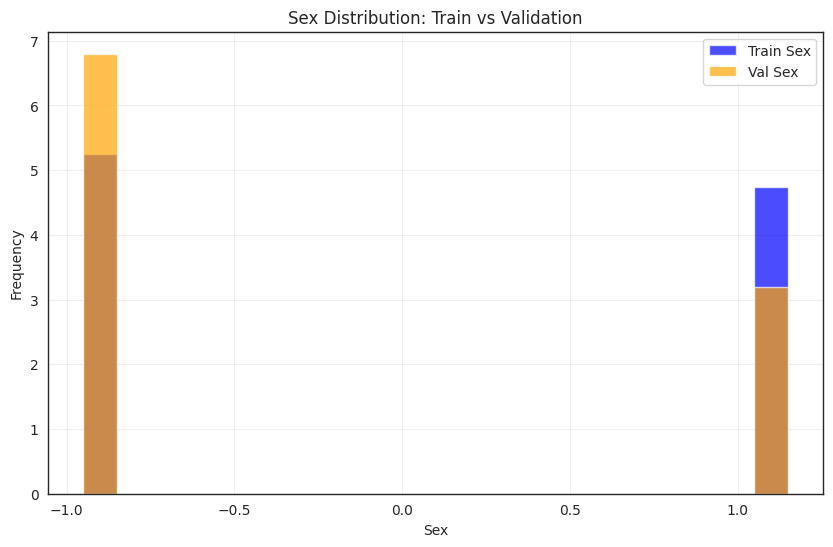

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate bin range to cover both datasets
min_sex = min(train_sex.min(), val_sex.min())
max_sex = max(train_sex.max(), val_sex.max())
bins = np.arange(min_sex, max_sex + 0.1, 0.1)

plt.figure(figsize=(10, 6))
plt.hist(train_sex.flatten(), bins=bins, alpha=0.7, label='Train Sex', color='blue', density=True)
plt.hist(val_sex.flatten(), bins=bins, alpha=0.7, label='Val Sex', color='orange', density=True)
plt.xlabel('Sex')
plt.ylabel('Frequency')
plt.title('Sex Distribution: Train vs Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

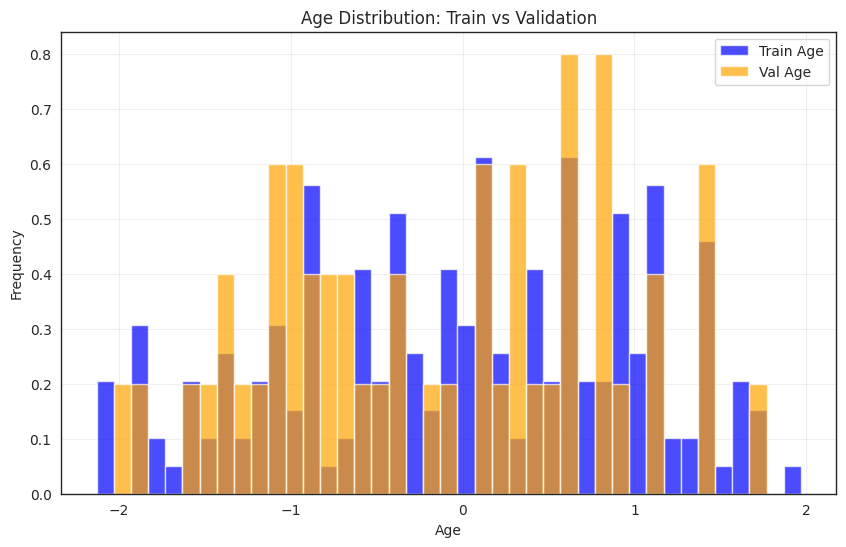

In [19]:
# Calculate bin range to cover both datasets
min_age = min(train_age.min(), val_age.min())
max_age = max(train_age.max(), val_age.max())
bins = np.arange(min_age, max_age + 0.1, 0.1)

plt.figure(figsize=(10, 6))
plt.hist(train_age.flatten(), bins=bins, alpha=0.7, label='Train Age', color='blue', density=True)
plt.hist(val_age.flatten(), bins=bins, alpha=0.7, label='Val Age', color='orange', density=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution: Train vs Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

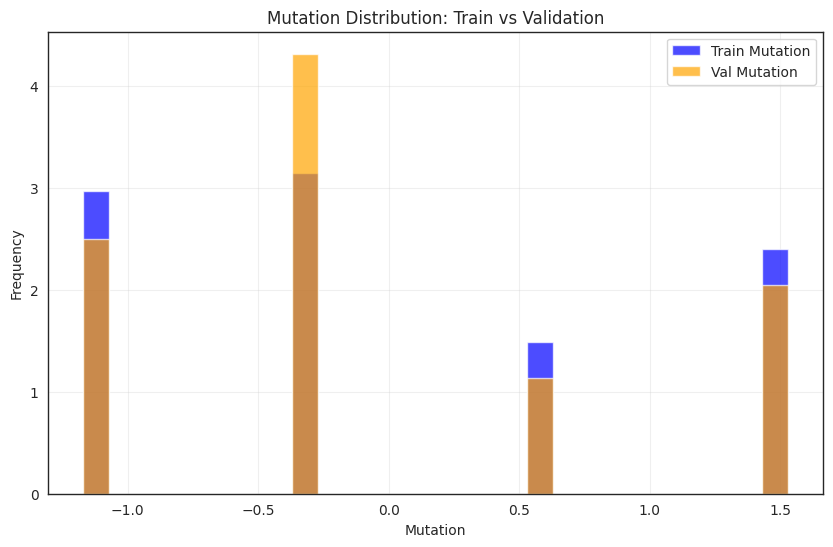

In [15]:
# Calculate bin range to cover both datasets
min_mutation = min(train_mutation.min(), val_mutation.min())
max_mutation = max(train_mutation.max(), val_mutation.max())
bins = np.arange(min_mutation, max_mutation + 0.1, 0.1)

plt.figure(figsize=(10, 6))
plt.hist(train_mutation.flatten(), bins=bins, alpha=0.7, label='Train Mutation', color='blue', density=True)
plt.hist(val_mutation.flatten(), bins=bins, alpha=0.7, label='Val Mutation', color='orange', density=True)
plt.xlabel('Mutation')
plt.ylabel('Frequency')
plt.title('Mutation Distribution: Train vs Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
run_lasso_folds(num_folds=5, expand_features=True)

Processed file names: ['FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_two_pass_True_train.pt', 'FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_two_pass_True_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_two_pass_True_train.pt
Processed file names: ['FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_two_pass_True_train.pt', 'FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_two_pass_True_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_

{np.float64(0.0001): [np.float64(0.6841249849196933),
  np.float64(0.6587046373850378),
  np.float64(0.40911553679920554),
  np.float64(0.44194248121840046),
  np.float64(0.41354187693096034)],
 np.float64(0.00013257113655901095): [np.float64(0.7096319581111097),
  np.float64(0.6403290077427791),
  np.float64(0.4340031765606706),
  np.float64(0.4341319635719454),
  np.float64(0.4393570877965732)],
 np.float64(0.00017575106248547912): [np.float64(0.7704093939931494),
  np.float64(0.6279230800387303),
  np.float64(0.4727653712523268),
  np.float64(0.4544089348451334),
  np.float64(0.4565437995699169)],
 np.float64(0.00023299518105153718): [np.float64(0.7816629542913741),
  np.float64(0.6014581330189578),
  np.float64(0.4922447347611306),
  np.float64(0.47426094214231596),
  np.float64(0.46310256177917264)],
 np.float64(0.00030888435964774815): [np.float64(0.7325206522126775),
  np.float64(0.6061283599372114),
  np.float64(0.47952911056769837),
  np.float64(0.47834222864995224),
  np.floa

In [17]:
run_lasso_folds(num_folds=5, expand_features=False)

Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_n

{np.float64(0.0001): [np.float64(0.7452082209831217),
  np.float64(0.5885696531128114),
  np.float64(1.0671477062486194),
  np.float64(0.643669623570088),
  np.float64(0.5157570432695628)],
 np.float64(0.00013257113655901095): [np.float64(0.7652010952532738),
  np.float64(0.5626686952823304),
  np.float64(1.0503653268187834),
  np.float64(0.5755241208657732),
  np.float64(0.45787117838813457)],
 np.float64(0.00017575106248547912): [np.float64(0.7839078057109088),
  np.float64(0.5328763256730632),
  np.float64(1.08089606755736),
  np.float64(0.5555989707091535),
  np.float64(0.41533951713565787)],
 np.float64(0.00023299518105153718): [np.float64(0.8315273530040385),
  np.float64(0.510851739683445),
  np.float64(1.1195932357363858),
  np.float64(0.6047431685446056),
  np.float64(0.3937444171833435)],
 np.float64(0.00030888435964774815): [np.float64(0.8644023637717991),
  np.float64(0.5011362733268233),
  np.float64(1.1356248435185816),
  np.float64(0.6321505752752704),
  np.float64(0.395

In [18]:
run_lasso_folds(num_folds=5, expand_features=True)

Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_train.pt', 'FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_nfl_wgcna_adj_thresh_0.5_num_nodes_7258_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_5fold_0_val.pt
Processed file names: ['FTD_y_val_nfl_wgcna_adj_thresh_0.5_n

{np.float64(0.0001): [np.float64(0.7452082209831214),
  np.float64(0.5885696531128094),
  np.float64(1.0671477062486177),
  np.float64(0.6436696235700892),
  np.float64(0.5157570432695622)],
 np.float64(0.00013257113655901095): [np.float64(0.7652010952532736),
  np.float64(0.5626686952823319),
  np.float64(1.0503653268187845),
  np.float64(0.5755241208657731),
  np.float64(0.457871178388135)],
 np.float64(0.00017575106248547912): [np.float64(0.7839078057109096),
  np.float64(0.5328763256730625),
  np.float64(1.0808960675573605),
  np.float64(0.5555989707091538),
  np.float64(0.41533951713565626)],
 np.float64(0.00023299518105153718): [np.float64(0.83152735300404),
  np.float64(0.5108517396834447),
  np.float64(1.1195932357363874),
  np.float64(0.6047431685446067),
  np.float64(0.3937444171833427)],
 np.float64(0.00030888435964774815): [np.float64(0.8644023637718001),
  np.float64(0.5011362733268236),
  np.float64(1.1356248435185814),
  np.float64(0.6321505752752703),
  np.float64(0.395

In [7]:
run_lasso_folds(num_folds=1, expand_features=True, k_fold=False)

Processed file names: ['FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_two_pass_True_train.pt', 'FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_two_pass_True_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/raw/cleanDat.Soma.CSFneat.5SDWinsor_merged.csv


Processing...


Number of patients with measurements: 248.0
Number of patients with mutation status in ['GRN', 'MAPT', 'C9orf72', 'CTL']: 248
Number of patients with sex in ['M', 'F']: 248
Total number of patients with all conditions 248
final dims of filtered data: (246, 4308)
Number of proteins: 3667
Mean and std saved to: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_train_random_state_42.json
Training features and labels: torch.Size([196, 3667, 1]) torch.Size([196])
Val features and labels: torch.Size([50, 3667, 1]) torch.Size([50])
Training sex, mutation and age labels shape: torch.Size([196, 1]) torch.Size([196, 1]) torch.Size([196, 1])
Val sex, mutation and age labels shape: torch.Size([50, 1]) torch.Size([50, 1]) torch.Size([50, 1])
   Power SFT.R.sq   slope truncated.R.sq mean.k. median.k. max.k.
1      1  0.94700  5.6400          0.971  2240.0   2320.00   2640
2      2  0.83300  1.920

Done!


Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_two_pass_True_train.pt
Processed file names: ['FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_two_pass_True_train.pt', 'FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_two_pass_True_val.pt']
Loading data from: /scratch/lcornelis/data/data_louisa/FTD/processed/FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_two_pass_True_val.pt
Processed file names: ['FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,CTL_csf_sex_M,F_random_state_42_two_pass_True_train.pt', 'FTD_y_val_global_cog_slope_wgcna_adj_thresh_0.5_num_nodes_3667_mutation_GRN,MAPT,C9orf72,C

{np.float64(0.0001): [np.float64(0.5839507110925711)],
 np.float64(0.00013257113655901095): [np.float64(0.5827489332216288)],
 np.float64(0.00017575106248547912): [np.float64(0.5986146712953615)],
 np.float64(0.00023299518105153718): [np.float64(0.6210462090660814)],
 np.float64(0.00030888435964774815): [np.float64(0.6495314215509634)],
 np.float64(0.00040949150623804275): [np.float64(0.667225801180678)],
 np.float64(0.0005428675439323859): [np.float64(0.6860419047578649)],
 np.float64(0.0007196856730011522): [np.float64(0.6896197387715016)],
 np.float64(0.0009540954763499944): [np.float64(0.7058092540827207)],
 np.float64(0.0012648552168552957): [np.float64(0.7004502832018789)],
 np.float64(0.0016768329368110084): [np.float64(0.6875896770725173)],
 np.float64(0.0022229964825261957): [np.float64(0.6909297378656812)],
 np.float64(0.0029470517025518097): [np.float64(0.703230622196362)],
 np.float64(0.003906939937054617): [np.float64(0.7079746038555935)],
 np.float64(0.005179474679231213)

In [20]:
During the k-fold -> 143 training samples, validating on 36 samples
Final evaluation -> 179 total training samples, testing on 45
7258 proteins

SyntaxError: invalid syntax (903581591.py, line 1)